In [1]:
#NAHEEM'S CODE

In [61]:
from heapq import merge

import numpy as np
from metloom.pointdata import SnotelPointData
import geopandas as gpd

import pandas as pd
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

from numpy.distutils.conv_template import header

C:\Users\RDCRLSMC\AppData\Local\Temp\4\ipykernel_25248\4082261670.py:12: DeprecationWarning: 

  `numpy.distutils` is deprecated since NumPy 1.23.0, as a result
  of the deprecation of `distutils` itself. It will be removed for
  Python >= 3.12. For older Python versions it will remain present.
  It is recommended to use `setuptools < 60.0` for those Python versions.
  For more details, see:
    https://numpy.org/devdocs/reference/distutils_status_migration.html 


  from numpy.distutils.conv_template import header


In [4]:
# pip install metloom

In [9]:
snotel_point = SnotelPointData("637:ID:SNTL", "MCS") # define the snotel ID

# get the daily data for the snotel site for the specified date range and variables
WY20 = snotel_point.get_daily_data(
    datetime(2019, 10, 1), datetime(2020, 10, 1),
    [snotel_point.ALLOWED_VARIABLES.SNOWDEPTH]
)

In [10]:

WY21 = snotel_point.get_daily_data(
    datetime(2020, 10, 1), datetime(2021, 10, 1),
    [snotel_point.ALLOWED_VARIABLES.SNOWDEPTH]
)

In [11]:

WY22 = snotel_point.get_daily_data(
    datetime(2021, 10, 1), datetime(2022, 10, 1),
    [snotel_point.ALLOWED_VARIABLES.SNOWDEPTH]
)

In [12]:

WY23 = snotel_point.get_daily_data(
    datetime(2022, 10, 1), datetime(2023, 10, 1),
    [snotel_point.ALLOWED_VARIABLES.SNOWDEPTH]
)

In [13]:

WY24 = snotel_point.get_daily_data(
    datetime(2023, 10, 1), datetime(2024, 10, 1),
    [snotel_point.ALLOWED_VARIABLES.SNOWDEPTH]
)

In [14]:

WY25 = snotel_point.get_daily_data(
    datetime(2024, 10, 1), datetime(2025, 10, 1),
    [snotel_point.ALLOWED_VARIABLES.SNOWDEPTH]
)
#df["SNOWDEPTH (m)"] = df["SNOWDEPTH"] * 0.0254 # convert snow depth from inches to meters
#df.to_csv("snotel_data.csv", index=False) # save the data to a csv file


In [ ]:
WY20.info()

In [31]:
WYS = [WY20,WY21,WY22,WY23,WY24,WY25]
merged = gpd.GeoDataFrame(pd.concat(WYS, ignore_index=False))

merged.head()

,,geometry,SNOWDEPTH,SNOWDEPTH_units,datasource
datetime,site,,,,
2019-10-01 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS
2019-10-02 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS
2019-10-03 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS
2019-10-04 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS
2019-10-05 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS


In [33]:

merged["SNOWDEPTH (m)"] = merged["SNOWDEPTH"] * 0.0254 # convert snow depth from inches to meters
merged.head()

,,geometry,SNOWDEPTH,SNOWDEPTH_units,datasource,SNOWDEPTH (m)
datetime,site,,,,,
2019-10-01 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,0.0
2019-10-02 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,0.0
2019-10-03 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,0.0
2019-10-04 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,0.0
2019-10-05 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,0.0


In [38]:
merged.to_csv("snotel_data.csv") # save the data to a csv file
merged.head()

,,geometry,SNOWDEPTH,SNOWDEPTH_units,datasource,SNOWDEPTH (m)
datetime,site,,,,,
2019-10-01 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,0.0
2019-10-02 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,0.0
2019-10-03 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,0.0
2019-10-04 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,0.0
2019-10-05 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,0.0


In [86]:
print(merged.index.names)

['datetime', 'site']


In [118]:
dates = merged.index.get_level_values('datetime')
month = dates.month
mask = ((month >= 10) | (month <= 5))
merged_filtered = merged.loc[mask]

merged_filtered.head()
#merged_filtered.to_csv("filtered_SNOTEL.csv")

,,geometry,SNOWDEPTH,SNOWDEPTH_units,datasource,SNOWDEPTH (m)
datetime,site,,,,,
2019-10-01 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,0.0
2019-10-02 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,0.0
2019-10-03 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,0.0
2019-10-04 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,0.0
2019-10-05 08:00:00+00:00,637:ID:SNTL,POINT Z (-115.66588 43.93200 6090.00000),0.0,in,NRCS,0.0


In [120]:
print(merged_filtered.index.names)


['datetime', 'site']


In [122]:
dates = merged_filtered.index.get_level_values('datetime')

snowdepth = merged_filtered['SNOWDEPTH (m)']

AttributeError: 'DatetimeIndex' object has no attribute 'index'

In [ ]:
LiDAR_dates = [
    '2020-02-09', '2021-03-15',  # added
    '2022-02-17', '2022-03-17', '2022-04-07',
    '2022-12-08', '2023-02-09', '2023-03-16',
    '2023-04-05', '2023-11-13', '2023-12-28',  # fixed 12-38 → 12-28
    '2024-01-15', '2024-02-13', '2024-03-15',
    '2024-04-28', '2025-01-25', '2025-01-29',
    '2025-04-04', '2025-05-01'
]

LiDAR_dates = pd.to_datetime(LiDAR_dates)

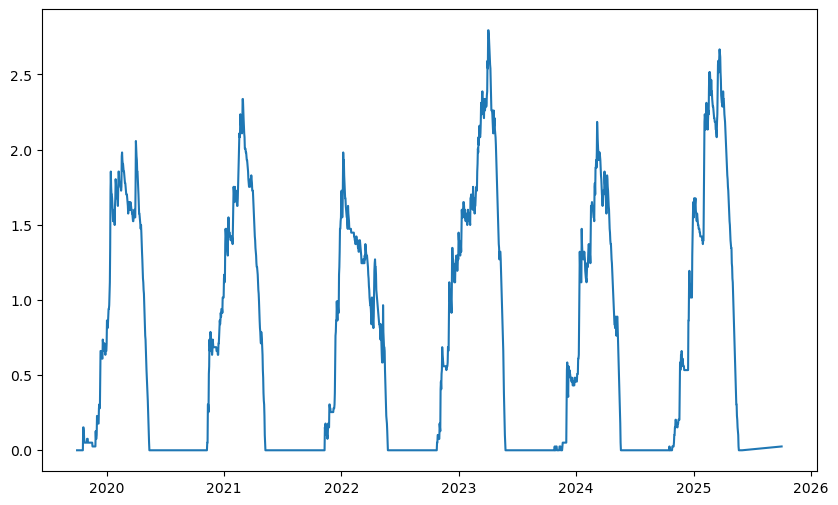

In [123]:
# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(dates, snowdepth, linestyle='-')

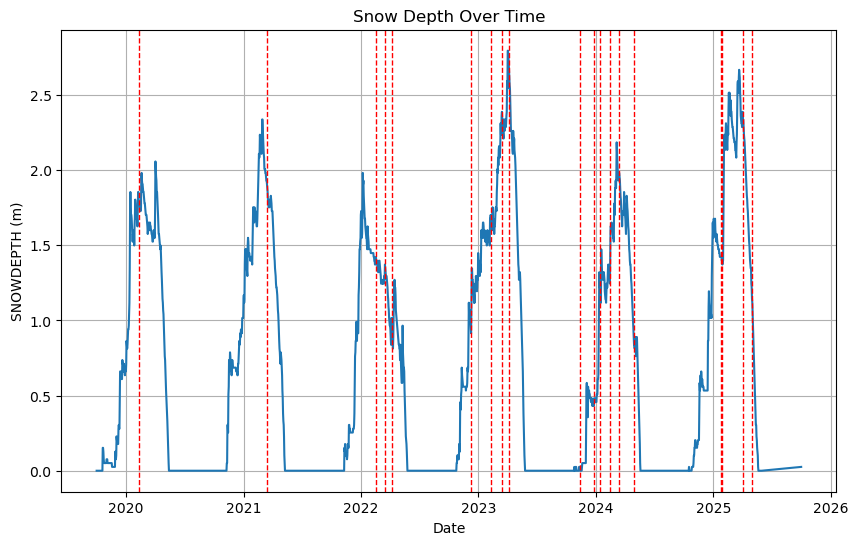

In [124]:

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(dates, snowdepth, linestyle='-')

for d in LiDAR_dates:
    plt.axvline(d, color='red', linestyle='--', linewidth=1)
    
plt.xlabel('Date')
plt.ylabel('SNOWDEPTH (m)')
plt.title('Snow Depth Over Time')
plt.grid(True)

# Format the x-axis to show only 5 labels
#plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(5))

plt.show()

merged type: <class 'geopandas.geodataframe.GeoDataFrame'>
Index type: <class 'pandas.core.indexes.multi.MultiIndex'>
Index levels: ['datetime', 'site']
Sample index values: MultiIndex([('2019-10-01 08:00:00+00:00', '637:ID:SNTL'),
            ('2019-10-02 08:00:00+00:00', '637:ID:SNTL'),
            ('2019-10-03 08:00:00+00:00', '637:ID:SNTL'),
            ('2019-10-04 08:00:00+00:00', '637:ID:SNTL'),
            ('2019-10-05 08:00:00+00:00', '637:ID:SNTL')],
           names=['datetime', 'site'])
Dates dtype: datetime64[ns, UTC]
Min, Max dates: 2019-10-01 08:00:00+00:00 2025-10-01 08:00:00+00:00
Total rows: 2184
Rows kept after month filter (Oct->Jun): 1646
Rows dropped (Jul-Sep): 538


TypeError: Invalid comparison between dtype=datetime64[ns] and Timestamp